In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../dataset/superstore.csv', encoding='cp1252')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [6]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())

In [12]:
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [17]:
df['order_date'].dtype

dtype('<M8[us]')

In [18]:
df['sales'] = pd.to_numeric(df['sales'])

In [19]:
df['year'] = df['order_date'].dt.year

In [20]:
df['month'] = df['order_date'].dt.month

In [21]:
df['month_name'] = df['order_date'].dt.month_name()

In [22]:
df['quarter'] = df['order_date'].dt.quarter

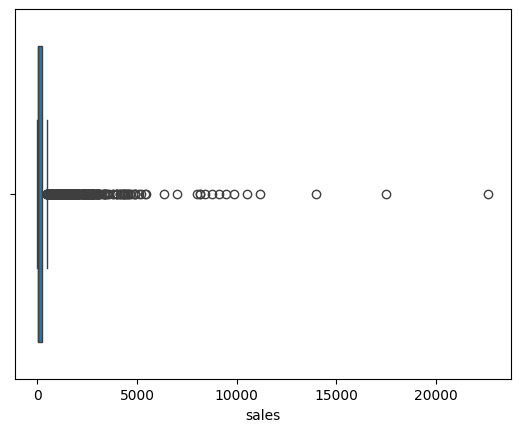

In [23]:
sns.boxplot(x=df['sales'])
plt.show()

In [24]:
Q1 = df['sales'].quantile(0.25)

In [25]:
Q3 = df['sales'].quantile(0.75)

In [26]:
IQR=Q3-Q1

In [27]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [28]:
df = df[(df['sales'] >= lower_limit) & (df['sales'] <= upper_limit)]

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 8827 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         8827 non-null   int64         
 1   order_id       8827 non-null   str           
 2   order_date     8827 non-null   datetime64[us]
 3   ship_date      8827 non-null   str           
 4   ship_mode      8827 non-null   str           
 5   customer_id    8827 non-null   str           
 6   customer_name  8827 non-null   str           
 7   segment        8827 non-null   str           
 8   country        8827 non-null   str           
 9   city           8827 non-null   str           
 10  state          8827 non-null   str           
 11  postal_code    8827 non-null   int64         
 12  region         8827 non-null   str           
 13  product_id     8827 non-null   str           
 14  category       8827 non-null   str           
 15  sub-category   8827 non-null   str   

In [30]:
df.describe()

,row_id,order_date,postal_code,sales,quantity,discount,profit,year,month,quarter
count,8827.000000,8827,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000
mean,5016.375892,2016-05-02 15:45:12.541067,55373.635663,92.864853,3.608587,0.157606,11.198644,2015.731732,7.784072,2.874929
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-1181.282400,2014.000000,1.000000,1.000000
25%,2508.500000,2015-05-28 00:00:00,23320.000000,15.008000,2.000000,0.000000,1.702400,2015.000000,5.000000,2.000000
50%,5028.000000,2016-07-01 00:00:00,59801.000000,40.880000,3.000000,0.200000,7.437600,2016.000000,9.000000,3.000000
75%,7517.500000,2017-05-15 00:00:00,90008.000000,124.225000,5.000000,0.200000,21.335400,2017.000000,11.000000,4.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,498.260000,14.000000,0.800000,240.859500,2017.000000,12.000000,4.000000
std,2888.406540,NaN,31974.536840,114.045078,2.129308,0.211531,49.066101,1.122496,3.289189,1.058986


In [31]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub-category,product_name,sales,quantity,discount,profit,year,month,month_name,quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,2016,11,November,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,2016,6,June,2
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,2015,10,October,4
5,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694,2014,6,June,2
6,7,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.280,4,0.0,1.9656,2014,6,June,2


In [32]:
df.to_csv('../processed/cleaned_sales_data.csv', index=False)